# TERRA-96M: node perturbation on held-out CRC Fibroblasts — **frozen vs. supervised fine-tuned**

Standalone copy of `terra_node_pert.ipynb` extended with a second arm: the same node-perturbation
benchmark run on an encoder **supervised fine-tuned on the domain key `typ`** (`232_REF` vs `232_CRC`),
compared against the frozen-pretrained arm. See `FINETUNE_PLAN.md` (approved 2026-09-14).

Model is **TERRA-96M**; holdout is **Fibroblast** in the cancer (CRC) region. Everything the fine-tuned
encoder touches is keyed `{TAG}_{MODEL}_{VARIANT}` so the two arms can never read each other's artifacts.
Fine-tuning is driven by `finetune_terra.py` (subprocess, §3 below); the benchmark itself is unchanged.

**TERRA-only.** No cellina import anywhere; the only shared code is `scripts/counterfactual_analysis.py`,
which depends on nothing but numpy/scanpy/decoupler/scipy/pandas/sklearn.

### How this differs from the TERRA tutorial

TERRA is a **JEPA** model: pretraining predicts *embeddings* of masked blocks, never counts, so there is no
reconstruction head. The published bundles (`model_checkpoint.pt`, `model_config.yaml`, `token_dictionary.pkl`,
`ensembl_dictionary.pkl`, `gene_count_dictionary.pkl`) ship **no decoder**. The tutorial therefore stops at a
per-niche W2 distance between unperturbed and perturbed embeddings.

Our benchmark is scored in **expression space** (Pearson *r* between observed and predicted logFC over the top
DE genes), so we add the one missing piece: `terra.training.decode`, a frozen-encoder NB probe
(`embedding -> negative-binomial mean`). The decoder is retrained per arm on that arm's embeddings.

### Design decisions (each verified against the TERRA source)

| Decision | Choice | Why |
|---|---|---|
| Readout | train `CountDecoder`, decode perturbed embeddings | JEPA has no native decoder; this is the only expression-space readout |
| Embedding | **`spatial_cell_emb`** | see the warning below — `cell_emb` cannot work |
| Coordinates | `px * 0.12028` -> `obsm['terra_spatial']` | µm; TERRA-96M sets `cell_pos_enc: coord`, so units are consumed by the model |
| Perturbation | **additive** shift in log1p space | `gene_expr` is `log1p(count)`; see §8 |
| Gene space | all ~18.9k genes in, 2000 HVGs out of the decoder | TERRA gets full context; decoder head stays learnable |
| Holdout | CRC Fibroblasts excluded from **decoder** training *and* from the fine-tuning pool | the decoder and the fine-tuned encoder are both leak paths |
| Fine-tuning selection | `selection_type: agg_cell` (**not** the tutorial's `agg_graph`) | `agg_graph` shapes `neighborhood_emb`; our decoder reads `spatial_cell_emb`, which is the `agg_cell` mask under full context (`embed.py:317`). Copying `agg_graph` would fine-tune a representation nothing downstream consumes. |

> ### ⚠️ `cell_emb` is provably invariant to neighbourhood perturbation
>
> `embed_dataset` runs two passes. From the `forward` docstring in `models/gene_transformers.py`:
> *"`need_cell_only_context`: if `True`, also run a second pass where queries in `[0:seq_len_cell)` **cannot
> attend to keys in `[seq_len_cell:)`**."*
>
> ```
> cell_emb         = mean(cell_only_ctx, cell_mask)          # own tokens, NO neighbour attention
> spatial_cell_emb = mean(full_ctx,      cell_mask)          # own tokens, full attention
> neighborhood_emb = mean(full_ctx,      neighborhood_mask)  # neighbour tokens
> ```
>
> `terra/training/decode.py` defaults to `--embed-key cell_emb`. Taking that default here would produce an
> exactly-zero counterfactual that looks like "TERRA cannot do node perturbation". We use `spatial_cell_emb`
> and **assert** in §9 that `cell_emb` is bit-identical between the base and perturbed passes.

## Caveats (`FINETUNE_PLAN.md` §11) — read before quoting any number below

1. **The patch is ours.** Upstream `finetune.py` as shipped rebuilds the encoder with the wrong config
   fields, `load_state_dict` raises, `terra/utils/helper.py:505` swallows it, and training proceeds from
   **random weights** — on both 112M and 96M. `finetune_terra.py` patches `init_model` (plan §4) and asserts
   the swallowed-exception log line never fires. State this plainly wherever the result is reported.
2. **`typ` gives 1 bit of supervision per cell.** REF vs CRC is a coarse, easy split; the gradient mostly
   carves out a single "cancer-ness" direction. This is why the frozen arm is mandatory.
3. **"96M" is the training corpus, not the parameter count.** The TERRA-96M encoder is **31,438,848**
   parameters.
4. **5 epochs is the tutorial's number on 9,320 cells.** Our fine-tuning pool is ~90k (printed in §3), so
   identical settings mean ~10x the gradient steps. We keep 5 and record the difference.
5. **Only 256 genes per cell reach the model.** Of ~496 detected genes, ~48 % are dropped by rank
   truncation, and with median 643 counts roughly 109 of the 256 slots are filled by an **unstable**
   tie-break among count-1 genes (`np.argsort`, quicksort, `tokenizers/tokenize.py:104`).
6. **TERRA and cellina score on different gene sets.** Overlap is **1063/2000 = 53.1 %**; 905 of cellina's
   HVGs are absent from TERRA's 9,477-gene vocabulary entirely. Cross-model comparison needs a common gene
   axis — unresolved, tracked separately.
7. **Train/inference special-token skew.** Fine-tuning's `BlockMaskCollator` omits `restrict_special_attention`
   and `special_token_pad_ratio=1.0`, and `init_cell_dataset` omits `pad_special_tokens=True`, all of which
   `embed.py:190-219` passes. Documented, not fixed (plan §6).
8. **Repacking the supervised checkpoint is our extension**, not an upstream feature: `finetune.py` saves
   `base_model.*` / `classification_head.*`, while `embed_dataset` reads `checkpoint['target_encoder']`
   (plan §5).

## 0. GPU selection

`embed_dataset` hardcodes `cuda:0` and takes no device argument, so the GPU must be chosen via `CUDA_VISIBLE_DEVICES` **before** torch is imported.

In [1]:
import os
# Physical GPU 0 (GPU 1 is occupied).
# Must be set before torch is imported -- embed_dataset() hardcodes cuda:0, so after
# this line "cuda:0" IS physical GPU 0.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys, json, pickle, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import torch
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
from datasets import load_from_disk

from terra import download_pretrained
from terra.inference import harmonize_adata, tokenize_adata, embed_dataset
from terra.training.decode import apply_count_decoder

# Metric helpers shared with the other LOO baselines (cellina / mintflow / spatialprop).
# This module imports only numpy/scanpy/decoupler/scipy/pandas/sklearn -- no cellina, no scvi.
sys.path.append("../../../scripts")
from counterfactual_analysis import (
    get_lfc, precision, direction_match,
    get_global_perturbation_logfc,
)

print("torch", torch.__version__, "| cuda", torch.version.cuda, "| available:", torch.cuda.is_available())
assert torch.cuda.is_available(), "TERRA requires a GPU"
print("visible GPU:", torch.cuda.get_device_name(0))

/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  warnings.warn(
/data/ddimitrov/software/miniforge3/envs/terra/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
torch 2.5.1+cu121 | cuda 12.1 | available: True
visible GPU: NVIDIA GeForce RTX 4090


## 1. Configuration

In [4]:
SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

MODEL_REPO = "lotfollahi-lab/TERRA-96M"    # plan section 2: cell_pos_enc=coord, count_encoding=mlp
DATA_ROOT  = os.environ.get("DATA_ROOT", "../../..")
DATA_PATH  = f"{DATA_ROOT}/data/crc_wt_cosmx/crc_232.h5ad"

CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)
OUT   = Path("output"); OUT.mkdir(exist_ok=True)

# Annotation keys (identical to cellina/docs/tutorial.ipynb)
LABELS_KEY, DOMAINS_KEY = "coarse_type", "typ"
HOLDOUT_CT     = "Fibroblast"
CONTROL_DOMAIN = "232_REF"
TARGET_DOMAIN  = "232_CRC"

# Plan section 7: every artifact is keyed by holdout AND model variant. Only the
# tokenised cache is unkeyed -- the three dictionaries are byte-identical across
# 112M/96M, so cache/crc232_tokenized is shared. The untagged cache/crc232_emb.npz
# is 112M and is NEVER read here.
MODEL = MODEL_REPO.split("-")[-1].lower()   # -> "96m"
TAG   = HOLDOUT_CT.lower()
print("MODEL", MODEL, "| TAG", TAG)

# Benchmark parity with notebooks/loo_benchmarks/cellina_node_pert.ipynb
N_PERT_GENES = 200
N_DEG        = 50

# CosMx pixel -> micron. The cellina tutorial encodes the same factor as
# `bandwidth = 100 / 0.12028` px for a 100 um bandwidth.
PX_TO_UM = 0.12028

# Gene-embedding-shift scoring (GENE_SHIFT_SPEC.md, protocol B)
GS_MIN_CELLS    = 20      # a gene needs this many control cells to get a cloud (paper's only floor: 20 cells)
GS_BLUR         = 0.01    # geomloss Sinkhorn blur (terra infer_token_distance default)
GS_N_RANDOM_SETS = 3      # random-gene control perturbations
GS_K            = N_DEG   # k for precision@k

EMBED_BATCH_SIZE = 32   # 2816-token sequences on a 24 GB 4090; raise if headroom allows
TOKENIZE_NPROC   = 16

MODEL 96m | TAG fibroblast


## 2. Load and label

Same coarse cell-type map as the cellina tutorial: `epi1-4` etc. are subtypes of one major type.

In [5]:
adata = sc.read_h5ad(DATA_PATH)
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial", "epi2": "Epithelial", "epi3": "Epithelial", "epi4": "Epithelial",
    "fib1": "Fibroblast", "fib2": "Fibroblast",
    "EC": "Endothelial", "SMC": "Smooth_muscle",
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell", "PC_IgG": "Plasma_cell", "PC_IgM": "Plasma_cell",
    "TC": "T_cell",
    "mye1": "Myeloid", "mye2": "Myeloid",
    "mast": "Mast_cell",
}
adata.obs[LABELS_KEY] = adata.obs["ist"].map(label_to_coarse)
adata = adata[~adata.obs[DOMAINS_KEY].isna()]
adata = adata[~adata.obs[LABELS_KEY].isna()].copy()

# TERRA matches cells by obs['cell_id'] throughout (tokenize -> embed -> perturb).
# The file already ships a 'cell_id' column and harmonize_adata only creates one when
# absent, so set it explicitly from the (unique) obs_names and keep it as str.
adata.obs["cell_id"] = adata.obs_names.astype(str)
assert adata.obs["cell_id"].is_unique

# CSC -> CSR: the tokenizer iterates cells (rows).
import scipy.sparse as sp
if sp.issparse(adata.X):
    adata.X = adata.X.tocsr()

print(adata.shape)
pd.crosstab(adata.obs[LABELS_KEY], adata.obs[DOMAINS_KEY])

(111989, 18936)


typ,232_CRC,232_REF
coarse_type,,
Endothelial,4994,1772
Epithelial,37319,12646
Fibroblast,20695,2881
Myeloid,5035,1033
Plasma_cell,7265,8387
Smooth_muscle,4157,1528
T_cell,2793,1484


## 3. Spatial coordinates

The tokenizer reads `adata.obsm['spatial']` (hardcoded, and passed to `squidpy.gr.spatial_neighbors`), and
`rel_x/rel_y` are raw coordinate **differences** fed to `sincos(omega * coord)` with no normalisation anywhere.
So units matter whenever the model uses `cell_pos_enc: coord`.

We build a new `obsm['terra_spatial']` in microns and never touch any existing key.

> For **TERRA-96M** — the model used here — this is load-bearing, not belt-and-braces: its config sets
> `cell_pos_enc: coord`, so the raw `rel_x`/`rel_y` differences are fed to `sincos(omega * coord)` and the
> unit **is** part of the input. (On TERRA-112M, `cell_pos_enc: segment`, so coordinates would affect only
> the kNN graph and the distance *ordering* of the 10 neighbours — both invariant to a positive rescaling.)

In [6]:
assert "spatial" not in adata.obsm, "refusing to overwrite an existing obsm['spatial']"

px = adata.obs[["CenterX_global_px", "CenterY_global_px"]].to_numpy(dtype=np.float64)
adata.obsm["terra_spatial"] = px * PX_TO_UM          # microns

# The tokenizer only ever reads obsm['spatial']; point it at the microns array.
adata.obsm["spatial"] = adata.obsm["terra_spatial"]

ext = np.ptp(adata.obsm["terra_spatial"], axis=0)
print(f"tissue extent: {ext[0]:.0f} x {ext[1]:.0f} um")

tissue extent: 4593 x 5624 um


## 4. Download the model and harmonize

Passing the bundle's own `ensembl_dictionary.pkl` and `gene_count_dictionary.pkl` avoids the multi-GB `pyensembl` release download and guarantees the gene vocabulary matches pretraining.

In [7]:
model_dir = download_pretrained(MODEL_REPO)
print("model bundle:", model_dir)
print(sorted(os.listdir(model_dir)))

['.gitattributes', 'README.md', 'ensembl_dictionary.pkl', 'gene_count_dictionary.pkl', 'model_checkpoint.pt', 'model_config.yaml', 'token_dictionary.pkl']


In [8]:
adata.layers["counts"] = adata.X.copy()   # keep raw counts; harmonize/tokenize consume .X

adata = harmonize_adata(
    adata,
    gene_mapping_dict_file_path=f"{model_dir}/ensembl_dictionary.pkl",
    gene_occurrence_count_file_path=f"{model_dir}/gene_count_dictionary.pkl",
)
print(f"after harmonise: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
adata.layers["counts"] = adata.X.copy()   # re-sync after gene/cell filtering

after harmonise: 111,989 cells x 9,477 genes


## 5. Tokenize (cached)

CPU-bound; builds the kNN graph (`n_neighs=10`) and the 11 x 256-token sequences.

In [9]:
TOK_CACHE = CACHE / "crc232_tokenized"
if TOK_CACHE.exists():
    tok = load_from_disk(str(TOK_CACHE))
    print("loaded cached tokenised dataset")
else:
    tok = tokenize_adata(adata, model_dir, str(CACHE / "tok_tmp"), nproc=TOKENIZE_NPROC)
    tok.save_to_disk(str(TOK_CACHE))
print(f"tokenised cells: {len(tok):,}")
print("columns:", list(tok.features))

loaded cached tokenised dataset
tokenised cells: 111,989
columns: ['rel_x_coord', 'rel_y_coord', 'cell_id', 'gene_tokens', 'gene_expr', 'n_nonzero_tokens']


## 6. Holdout masks

TERRA is fine-tuned on `~is_holdout` and the decoder trains on `~is_holdout`, so the held-out CRC
Fibroblasts are the ground truth of the benchmark and enter **neither**. `get_global_perturbation_logfc`
applies the same exclusion when it estimates the shift.

In [10]:
is_holdout = ((adata.obs[DOMAINS_KEY] == TARGET_DOMAIN) &
              (adata.obs[LABELS_KEY] == HOLDOUT_CT)).to_numpy()
is_control = ((adata.obs[DOMAINS_KEY] == CONTROL_DOMAIN) &
              (adata.obs[LABELS_KEY] == HOLDOUT_CT)).to_numpy()
adata.obs["is_holdout"] = is_holdout

print(f"control (REF {HOLDOUT_CT}) : {is_control.sum():,}")
print(f"target  (CRC {HOLDOUT_CT}) : {is_holdout.sum():,}")
print(f"decoder train              : {(~is_holdout).sum():,}")

# The decoder split h5ads are written per arm inside run_arm() -- they carry that
# arm's embeddings in .obsm, so they are keyed {TAG}_{MODEL}_{VARIANT}.

control (REF Fibroblast) : 2,881
target  (CRC Fibroblast) : 20,695
decoder train              : 91,294


## 7. Supervised fine-tuning (driver script)

`finetune_terra.py` does everything that must not live in a notebook: the stratified 90/10 split of the
pool, the `init_model` patch (plan §4), the pre-flight `strict=True` load, the runtime `_LoadGuard`
assert, training, the repack of `base_model.*` -> `target_encoder` (plan §5), and the post-repack load
check. It writes `ft_summary.json` into the bundle directory, printed below.

The fine-tuning pool is `~is_holdout` — the same mask the decoder uses. Hyperparameters are the tutorial's
verbatim (`lr 1e-4`, 5 epochs, batch 100, `use_peft: False`, block-11 targets), with the single deliberate
deviation `selection_type: agg_cell` documented at the top.

In [11]:
FT_POOL   = OUT / f"ft_pool_{TAG}.h5ad"
RUN_DIR   = OUT / f"ft_{TAG}_{MODEL}"
BUNDLE_DIR = OUT / f"ft_bundle_{TAG}_{MODEL}"

if FT_POOL.exists():
    # Same stale-split guard as the decoder splits: a pool left over from another holdout.
    n_cached = sc.read_h5ad(FT_POOL, backed="r").n_obs
    assert n_cached == int((~is_holdout).sum()), (
        f"stale split: {FT_POOL} has {n_cached} cells, "
        f"{HOLDOUT_CT} fine-tuning pool has {int((~is_holdout).sum())}. Delete it and re-run.")
    print("reusing", FT_POOL, f"({n_cached:,} cells)")
else:
    adata[~is_holdout].copy().write_h5ad(FT_POOL)
    print("wrote", FT_POOL, f"({int((~is_holdout).sum()):,} cells)")

reusing output/ft_pool_fibroblast.h5ad (91,294 cells)


In [12]:
ft_cmd = [
    sys.executable, "finetune_terra.py",
    "--model-dir",  str(model_dir),
    "--tok-cache",  str(TOK_CACHE),
    "--pool-h5ad",  str(FT_POOL),
    "--run-dir",    str(RUN_DIR),
    "--bundle-dir", str(BUNDLE_DIR),
    "--label", "typ",
    "--epochs", "5",
    "--batch-size", "100",
]
FT_SUMMARY = BUNDLE_DIR / "ft_summary.json"
if not FT_SUMMARY.exists():
    print(" ".join(ft_cmd))
    subprocess.run(ft_cmd, check=True)
else:
    print("using existing bundle", BUNDLE_DIR)

print(FT_SUMMARY.read_text())

using existing bundle output/ft_bundle_fibroblast_96m
{
  "val_accuracy_per_epoch": [
    "Epoch [1/5], Train Loss: 0.1664, Train Acc: 0.9241, Val Loss: 0.1187, Val Acc: 0.9481",
    "Epoch [2/5], Train Loss: 0.1049, Train Acc: 0.9541, Val Loss: 0.1015, Val Acc: 0.9594",
    "Epoch [3/5], Train Loss: 0.0858, Train Acc: 0.9637, Val Loss: 0.0907, Val Acc: 0.9629",
    "Epoch [4/5], Train Loss: 0.0720, Train Acc: 0.9700, Val Loss: 0.0799, Val Acc: 0.9674",
    "Epoch [5/5], Train Loss: 0.0595, Train Acc: 0.9752, Val Loss: 0.0752, Val Acc: 0.9699"
  ],
  "final_val_accuracy": 0.9698795180722891,
  "val_majority_class_rate": 0.6743702081051479,
  "n_train": 82164,
  "n_val": 9130,
  "classes": [
    "232_CRC",
    "232_REF"
  ],
  "num_classes": 2,
  "trainable_params": 1772928,
  "total_params": 31438848,
  "wall_seconds": 5796.4594004154205,
  "train_seconds": 5254.397827625275,
  "val_seconds": 446.0684759616852,
  "steps_per_epoch": 822,
  "seconds_per_step": 1.2784422938261009,
  "peak

## 8. The node perturbation

**What we shift.** The observed healthy -> cancer logFC, estimated by pseudobulk over all cell types
*except* the holdout (`get_global_perturbation_logfc`), restricted to the top `N_PERT_GENES` by `|logFC|`.
Using the global rather than the holdout-cell-type-specific shift is what keeps the counterfactual honest: the model is
never handed the true Fibroblast change it is asked to predict.

**How we shift it.** TERRA stores `gene_expr = log1p(count)` (`count_count_norm_method: shifted_log`, with both
`count_cell_norm_method` and `count_gene_norm_method` null — so no library normalisation). `perturb_dataset`'s
`foldchange` type *multiplies* that value, which is not a fold change on counts: for COL1A1 (delta = 2.49)
`exp(delta) = 12x` would send `log1p(2) = 1.10 -> 13.2`, a count of ~5e5.

An **additive** shift in the same log space is the correct operation, and is exactly what cellina's
`make_neighbor_perturbation(..., base=np.e, add_shift=True)` does:

$$\log(1+x) + \delta \;\Longleftrightarrow\; (1+x) \mapsto (1+x)\,e^{\delta}$$

so we apply it directly with a `datasets.map`. Only the **neighbourhood** segment `[256:]` is touched — the
focal cell's own tokens `[0:256]` are left untouched, which is what makes §9's `cell_emb` assertion meaningful.
Genes with zero expression stay zero (an undetected transcript cannot be perturbed), and the result is clipped
at 0 since `log1p` cannot be negative.

In [13]:
logfc = get_global_perturbation_logfc(
    adata, control_domain=CONTROL_DOMAIN, holdout_domain=TARGET_DOMAIN,
    labels_key=LABELS_KEY, domains_key=DOMAINS_KEY, holdout_ct=HOLDOUT_CT,
)
# Guard: an empty control or target group silently yields all-NaN, which would
# propagate into every perturbed token and produce NaN embeddings.
assert np.isfinite(logfc).all(), "logFC contains non-finite values"

top_genes = logfc.abs().nlargest(N_PERT_GENES).index
print(logfc[top_genes].head(10).round(3).to_string())
# (verification check 8: logFC finite.)

gene_name
S100A4     2.370
JCHAIN    -2.310
FABP1      1.795
S100A6     1.549
CHGA      -1.513
GSTP1      1.450
MIF        1.416
CEACAM5    1.378
IFI27      1.323
HSPA1A    -1.322


In [14]:
# gene symbol -> ensembl id -> TERRA token id
with open(f"{model_dir}/token_dictionary.pkl", "rb") as f:
    token_dict = pickle.load(f)

sym2ens = adata.var["ensembl_id"].to_dict()
VOCAB = max(token_dict.values()) + 1
delta = np.zeros(VOCAB, dtype=np.float64)

n_mapped = 0
for g in top_genes:
    tid = token_dict.get(sym2ens.get(g))
    if tid is not None:
        delta[tid] = logfc[g]
        n_mapped += 1
print(f"{n_mapped}/{N_PERT_GENES} perturbation genes mapped to TERRA tokens")

200/200 perturbation genes mapped to TERRA tokens


In [15]:
SEQ_LEN_CELL = 256   # model_config['data']['seq_len_cell']

def shift_neighbourhood(batch, d=None):
    # Add the log-space logFC to neighbour tokens only. Cell segment [0:256] untouched.
    # `d` overrides the real `delta` -- used for the random-gene controls below.
    d = delta if d is None else d
    tokens = np.asarray(batch["gene_tokens"])
    expr   = np.asarray(batch["gene_expr"], dtype=np.float64)

    nb_tok  = tokens[:, SEQ_LEN_CELL:]
    nb_expr = expr[:, SEQ_LEN_CELL:]
    shift = d[nb_tok]
    shift[nb_expr <= 0] = 0.0                       # undetected / padded genes are not perturbable
    expr[:, SEQ_LEN_CELL:] = np.clip(nb_expr + shift, 0.0, None)

    batch["gene_tokens"] = tokens
    batch["gene_expr"]   = expr
    return batch

# Only the control cells need a perturbed pass: each tokenised row already carries its own
# neighbourhood, so the subset is self-contained.
tok_ids  = [str(c) for c in tok.with_format(None)["cell_id"]]
pos_of   = {c: i for i, c in enumerate(tok_ids)}
ctrl_ids = adata.obs.loc[is_control, "cell_id"].astype(str).tolist()
ctrl_tok = tok.select([pos_of[c] for c in ctrl_ids])
assert [str(c) for c in ctrl_tok.with_format(None)["cell_id"]] == ctrl_ids

# Map with the torch format OFF -- this is what terra's own perturb_dataset does
# ("formatting the large nested token columns inside .map can stall"); restore it after.
_fmt = ctrl_tok.format
pert_tok = ctrl_tok.with_format(None).map(shift_neighbourhood, batched=True, batch_size=256)
pert_tok.set_format(type=_fmt["type"], columns=_fmt["columns"],
                    output_all_columns=_fmt["output_all_columns"])

_e0 = np.asarray(ctrl_tok.with_format(None)["gene_expr"], dtype=np.float64)
_e1 = np.asarray(pert_tok.with_format(None)["gene_expr"], dtype=np.float64)
print(f"perturbed {len(pert_tok):,} control cells")
print(f"  cell segment  [0:256] max |change| : {np.abs(_e0[:, :SEQ_LEN_CELL] - _e1[:, :SEQ_LEN_CELL]).max():.3e}  (must be 0)")
print(f"  neigh segment [256:]  max |change| : {np.abs(_e0[:, SEQ_LEN_CELL:] - _e1[:, SEQ_LEN_CELL:]).max():.3e}")
print(f"  neighbourhood tokens shifted/cell  : {(np.abs(_e0[:, SEQ_LEN_CELL:] - _e1[:, SEQ_LEN_CELL:]) > 0).sum(1).mean():.1f} of 2560")
assert np.abs(_e0[:, :SEQ_LEN_CELL] - _e1[:, :SEQ_LEN_CELL]).max() == 0, "cell segment was modified"
del _e0, _e1

perturbed 2,881 control cells
  cell segment  [0:256] max |change| : 0.000e+00  (must be 0)
  neigh segment [256:]  max |change| : 2.370e+00
  neighbourhood tokens shifted/cell  : 86.8 of 2560


In [16]:
# Random-gene control perturbations (GENE_SHIFT_SPEC.md section 5): the SAME logFC
# values applied to randomly drawn tokens that actually occur in the control cells'
# neighbourhood segment. Built once, before either arm runs, so both arms are scored
# against identical controls.
_nb_pool = np.unique(np.asarray(ctrl_tok.with_format(None)["gene_tokens"])[:, SEQ_LEN_CELL:])
_nb_pool = _nb_pool[_nb_pool != 0]
_vals    = delta[delta != 0]

rand_toks = []
for _i in range(GS_N_RANDOM_SETS):
    _d = np.zeros(VOCAB, dtype=np.float64)
    _d[np.random.default_rng(SEED + _i).choice(_nb_pool, len(_vals), replace=False)] = _vals
    _r = ctrl_tok.with_format(None).map(shift_neighbourhood, batched=True, batch_size=256,
                                        fn_kwargs={"d": _d})
    _r.set_format(type=_fmt["type"], columns=_fmt["columns"],
                  output_all_columns=_fmt["output_all_columns"])
    rand_toks.append(_r)

print(f"{len(rand_toks)} random-gene control sets: {len(_vals)} tokens each, "
      f"drawn from the {len(_nb_pool)} tokens present in the control neighbourhoods")


## 8b. Paper-style gene-embedding shift (protocol B)

`GENE_SHIFT_SPEC.md`. This is the TERRA preprint's own in-silico-perturbation readout, and it needs **no
decoder**: for every gene, its contextualised token embeddings across the control cells form a point cloud
(L2-normalised, as in `summarize_distance._l2_normalize_rows`); the gene's score is the entropic
**W2 / Sinkhorn divergence** between its unperturbed and its perturbed cloud. Genes are ranked by that score
and the ranking is scored against the real REF→CRC Fibroblast `|log2FC|`.

Three things to keep in mind when reading the table:

- **W2 is unsigned.** It says *how far* a gene's representation moved, never *which way*. So the only honest
  comparison against the ground truth is against `|log2FC|` — precision@k and correlations here are unsigned,
  and a gene that the model correctly moves in the wrong direction scores exactly the same as one it moves
  right. That is a property of the paper's statistic, not of this implementation.
- **The clouds use the cell's own token slots `[0:256]` under full attention** (`token_emb` is `n_emb`,
  `embed.py:283`). The perturbation only touches the neighbourhood segment `[256:]`, so the token *layout*
  is identical between the two passes and each gene's two clouds are point-for-point paired.
- **Why the "minus perturbed genes" universe exists.** The 200 genes we perturbed are also, by construction,
  the 200 largest `|log2FC|` genes — they sit at the top of the ground-truth ranking *and* their own tokens
  are the ones whose values were changed in the neighbourhood. Any precision@k computed over all genes is
  therefore partly a measurement of the intervention we performed, not of what the model inferred. Row (iii)
  removes them from both the ranking and the truth; it is the row that answers "did the model propagate the
  perturbation to genes we did **not** touch?".

Controls: `GS_N_RANDOM_SETS` random-gene perturbations (same logFC values, random neighbour tokens) plus the
analytic chance line `GS_K / |universe|`.

In [17]:
import time
from geomloss import SamplesLoss
from terra.training.decode import compute_hvgs


def _dense(m):
    return np.asarray(m.todense()) if sp.issparse(m) else np.asarray(m)


# Universe (ii): the decoder's 2000 HVGs. The checkpoint does not exist yet at the
# point run_arm calls the scorer, so we recompute the list with the decoder's OWN
# selector (`terra.training.decode.compute_hvgs`) on the same training split and the
# same flags run_arm passes it (seurat_v3, layer "counts", top 2000). Deterministic and
# identical for both arms. Only deviation: decode.py additionally drops zero-variance
# genes from its gene_list afterwards.
HVG2000 = set(compute_hvgs(adata[~is_holdout], n_top_genes=2000,
                           flavor="seurat_v3", counts_layer="counts"))

# Ground truth |log2FC|: REF Fibroblast -> CRC Fibroblast pseudobulk over the FULL
# harmonised gene axis (NOT the HVGs -- that is only universe (ii)), with get_lfc's own
# CP10K normalisation: per-cell counts/sum*1e4, mean over cells, safe log2 ratio.
_c = _dense(adata.layers["counts"][is_control])
GT_LFC = pd.Series(
    get_lfc(control=_c, target=_dense(adata.layers["counts"][is_holdout]),
            counterfactual=_c, n_deg=1)[0],
    index=adata.var_names.astype(str))
del _c

# TERRA token id -> gene symbol. Tokens with no symbol in adata.var get no ground truth.
TOK2SYM = {token_dict[e]: g for g, e in sym2ens.items() if e in token_dict}
print(f"HVG2000: {len(HVG2000)} | ground truth over {len(GT_LFC)} genes | "
      f"{len(TOK2SYM)} tokens carry a symbol")


def _token_cloud(model_folder, ds):
    """The cell's own token embeddings under FULL neighbourhood attention, flattened to
    (n_cells * 256, 384) and L2-normalised, on the GPU."""
    out = embed_dataset(dataset=ds, **dict(EMB_KWARGS, model_folder_path=str(model_folder),
                                           return_token_embeddings=True))
    # token_emb IS n_emb: all 2816 positions (96M has special_tokens: [], so position i
    # is gene_tokens[i]). ~12.5 GB fp32 for 2,881 cells -- slice to 1.1 GB and drop it.
    emb = torch.from_numpy(np.ascontiguousarray(out["token_emb"][:, :SEQ_LEN_CELL]))
    del out
    emb = emb.reshape(-1, emb.shape[-1]).to("cuda:0", torch.float32)
    return emb / (emb.norm(dim=1, keepdim=True) + 1e-12)      # _l2_normalize_rows


def score_gene_shift(model_folder, variant, ctrl_tok, pert_tok, rand_toks=(), out_csv=None):
    """Rank genes by the W2 between their control and perturbed token clouds and score
    that ranking against the real |log2FC|. Returns one row per universe x method."""
    out_csv = Path(out_csv or OUT / f"gene_shift_{TAG}_{MODEL}_{variant}.csv")
    if out_csv.exists():
        print("using cached", out_csv)
        return pd.read_csv(out_csv)
    t0 = time.time()

    tokens = np.asarray(ctrl_tok.with_format(None)["gene_tokens"])[:, :SEQ_LEN_CELL]
    assert (np.asarray(pert_tok.with_format(None)["gene_tokens"])[:, :SEQ_LEN_CELL]
            == tokens).all(), "cell-segment token layout moved -- clouds are not paired"

    n_per_tok = np.bincount(tokens.ravel(), minlength=VOCAB)
    n_per_tok[0] = 0                                            # pad token
    cand  = np.flatnonzero(n_per_tok >= GS_MIN_CELLS)
    utok  = np.array([t for t in cand if TOK2SYM.get(t) in GT_LFC.index])
    n_dropped = len(cand) - len(utok)
    genes = np.array([TOK2SYM[t] for t in utok])
    truth = GT_LFC.loc[genes].abs().to_numpy()

    # Per-gene occurrence positions, without materialising an (n_genes, n_cells) mask.
    flat  = tokens.ravel()
    order = np.argsort(flat, kind="stable")
    lo = np.searchsorted(flat[order], utok, "left")
    hi = np.searchsorted(flat[order], utok, "right")
    pos = torch.from_numpy(order).to("cuda:0")

    loss_fn = SamplesLoss("sinkhorn", p=2, blur=GS_BLUR, backend="tensorized")
    base = _token_cloud(model_folder, ctrl_tok)

    def w2_against(ds):
        other = _token_cloud(model_folder, ds)
        d = np.array([float(loss_fn(base[pos[lo[i]:hi[i]]], other[pos[lo[i]:hi[i]]]))
                      for i in range(len(utok))])
        del other; torch.cuda.empty_cache()
        return d

    shifts = {"pipeline": w2_against(pert_tok)}
    for i, rt in enumerate(rand_toks, 1):
        shifts[f"random_{i}"] = w2_against(rt)
    self_w2 = float(loss_fn(base[pos[lo[0]:hi[0]]], base[pos[lo[0]:hi[0]]]))
    del base; torch.cuda.empty_cache()

    not_perturbed = ~np.isin(utok, np.flatnonzero(delta != 0))
    n_pert_present = int((~not_perturbed).sum())
    uni = {"(i) all token-covered":       np.ones(len(utok), bool),
           "(ii) n decoder HVG2000":      np.isin(genes, list(HVG2000)),
           "(iii) minus perturbed genes": not_perturbed}

    rows = []
    for uname, m in uni.items():
        t, n = truth[m], int(m.sum())
        for sname, w in shifts.items():
            rows.append(dict(arm=f"{variant}: {sname}", universe=uname, n_genes=n,
                             prec_at_k=precision(t, w[m], k=GS_K),
                             pearson=pearsonr(t, w[m])[0], spearman=spearmanr(t, w[m])[0]))
        rows.append(dict(arm=f"{variant}: chance", universe=uname, n_genes=n,
                         prec_at_k=GS_K / n, pearson=np.nan, spearman=np.nan))
    df = pd.DataFrame(rows)

    assert np.isfinite(np.concatenate(list(shifts.values()))).all(), "non-finite W2"
    assert self_w2 < 1e-3, f"W2 of a cloud against itself is {self_w2:.3e}, not ~0"
    assert int(not_perturbed.sum()) == len(utok) - n_pert_present, "universe (iii) size"
    assert df["prec_at_k"].between(0, 1).all(), "precision@k outside [0, 1]"

    df.to_csv(out_csv, index=False)
    print(f"[{variant}] gene shift: |universe|={len(utok)} genes in >= {GS_MIN_CELLS} "
          f"control cells | {n_dropped} tokens dropped (no ground truth in adata.var) | "
          f"{n_pert_present} perturbed genes present | self-W2={self_w2:.2e} | "
          f"{len(rand_toks)} random sets | {time.time() - t0:.0f}s -> {out_csv}")
    return df


HVG2000: 2000 | ground truth over 9477 genes | 9477 tokens carry a symbol


## 9. The benchmark arm

Everything downstream of the tokenised dataset depends on the encoder, so it is one function run twice:

```
embed all cells (cached) -> attach obsm -> write decoder splits -> train decoder
 -> embed base+perturbed control cells -> decode -> score -> figure
```

Decoder flags are copied verbatim from `terra_node_pert.ipynb` cell 22:

- `--embed-key spatial_cell_emb` — **not** the `cell_emb` default (see the warning at the top).
- `--loss-type nb_libsize` — true library size in training, fixed 10k at test, i.e. CP10K output, matching
  `_normalize_counts(scale=1e4)` in `counterfactual_analysis.get_lfc`.
- `--gene-selection hvg --hvg-top-n 2000` — decoder output space.
- `--disable-slide-batching` — load-bearing: there is no `slide` column, so slide ids are per-cell and
  slide-homogeneous batches would each hold a single cell.

`apply_count_decoder` requires `var_names` to equal the checkpoint's `gene_list`, so we subset to the
decoder's 2000 HVGs first. Ground truth (`control`, `target`) is read from the raw counts — never from TERRA.

Scoring (plan §8), per arm:
**(a)** pearson/spearman/prec@20/dir on the top-50 DE genes — parity with `cellina_node_pert.ipynb`;
**(b)** `pearson(true_lfc, pred_lfc - null_lfc)` — the primary metric, where the null is the decode of the
**unperturbed** re-embed of the same control cells; **(c)** the A/B/A' baselines of
`checks/check_baselines.py` (A and A' use no TERRA at all, so they are computed once, on the frozen arm).

In [18]:
from adjustText import adjust_text

def plot_lfc(true_lfc, pred_lfc, deg, gene_names, holdout_ct, pearson):
    fig, ax = plt.subplots(figsize=(6, 5.5))
    deg = np.asarray(deg)
    non_deg = np.setdiff1d(np.arange(len(true_lfc)), deg)
    ax.scatter(true_lfc[non_deg], pred_lfc[non_deg], alpha=0.25, s=8,
               color="lightgray", linewidths=0, rasterized=True)
    up, down = deg[true_lfc[deg] >= 0], deg[true_lfc[deg] < 0]
    ax.scatter(true_lfc[up], pred_lfc[up], s=45, color="#d62728",
               edgecolor="white", linewidths=0.5, zorder=3, label="up in cancer")
    ax.scatter(true_lfc[down], pred_lfc[down], s=45, color="#1f77b4",
               edgecolor="white", linewidths=0.5, zorder=3, label="down in cancer")
    texts = [ax.text(true_lfc[i], pred_lfc[i], gene_names[i], fontsize=8) for i in deg]
    adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.6", lw=0.5))
    lo, hi = float(min(true_lfc.min(), pred_lfc.min())), float(max(true_lfc.max(), pred_lfc.max()))
    pad = 0.05 * (hi - lo); lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, alpha=0.6, zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_xlabel("Observed logFC  (control -> cancer)")
    ax.set_ylabel("Predicted logFC  (TERRA counterfactual)")
    ax.set_title(f"{holdout_ct}: observed vs. predicted logFC   (Pearson r = {pearson:.2f})")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    fig.tight_layout()
    return fig

In [19]:
EMB_KEYS   = ["cell_emb", "spatial_cell_emb", "neighborhood_emb"]
EMB_KWARGS = dict(emb_layer=None, agg_excluded_genes=None, top_k=None,
                  batch_size=EMBED_BATCH_SIZE, include_spatial_cell_emb=True,
                  return_token_embeddings=False, ignore_spc_tokens=True, num_workers=8)

def run_arm(model_folder, variant):
    """One encoder -> embeddings -> decoder -> counterfactual -> scores. variant in {frozen, ft}."""
    key = f"{TAG}_{MODEL}_{variant}"
    kw  = dict(EMB_KWARGS, model_folder_path=str(model_folder))
    res = {"variant": variant}
    print(f"===== arm {variant}  ({model_folder}) =====")

    # --- embed every cell (cached; keyed by model, and by holdout for the ft encoder) ---
    emb_cache = CACHE / (f"crc232_emb_{MODEL}_frozen.npz" if variant == "frozen"
                         else f"crc232_emb_{MODEL}_ft_{TAG}.npz")
    if emb_cache.exists():
        _z = np.load(emb_cache, allow_pickle=True)
        base_emb = {k: _z[k] for k in EMB_KEYS}
        base_ids = list(_z["cell_id"])
        print("loaded cached embeddings", emb_cache)
    else:
        base = embed_dataset(dataset=tok, **kw)
        base_ids = list(tok.with_format(None)["cell_id"])
        base_emb = {k: np.asarray(base[k]) for k in EMB_KEYS}
        np.savez_compressed(emb_cache, cell_id=np.array(base_ids, dtype=object), **base_emb)
        print("wrote", emb_cache)

    obs_ids = adata.obs["cell_id"].astype(str)
    for k in EMB_KEYS:
        df  = pd.DataFrame(base_emb[k], index=[str(c) for c in base_ids])
        arr = df.reindex(obs_ids).to_numpy(dtype=np.float32)
        assert not np.isnan(arr).any(), f"{k}: some cells missing an embedding"
        adata.obsm[k] = arr
    res["scemb"] = adata.obsm["spatial_cell_emb"].copy()   # kept for checks 4-5
    del base_emb

    # --- paper-style gene-embedding shift (section 8b); decoder-free, so it runs here ---
    res["gene_shift"] = score_gene_shift(model_folder, variant, ctrl_tok, pert_tok, rand_toks)
    print(res["gene_shift"].round(4).to_string(index=False))

    # --- decoder splits (variant-keyed: the .obsm they carry is this arm's) ---
    train_h5ad = OUT / f"decoder_train_{key}.h5ad"
    test_h5ad  = OUT / f"decoder_test_{key}.h5ad"
    if train_h5ad.exists() and test_h5ad.exists():
        print("reusing", train_h5ad, test_h5ad)
    else:
        adata[~is_holdout].copy().write_h5ad(train_h5ad)
        adata[is_holdout].copy().write_h5ad(test_h5ad)
        print("wrote", train_h5ad, test_h5ad)
    res["n_test"] = int(sc.read_h5ad(test_h5ad, backed="r").n_obs)
    assert res["n_test"] == int(is_holdout.sum()), (          # check 7
        f"stale split: {test_h5ad} has {res['n_test']} cells, {HOLDOUT_CT} holdout has "
        f"{int(is_holdout.sum())}. Delete it and re-run.")

    # --- count decoder (flags verbatim from terra_node_pert.ipynb cell 22) ---
    ckpt        = OUT / f"count_decoder_{key}.pt"
    dec_metrics = OUT / f"decoder_metrics_{key}.json"
    cmd = [
        sys.executable, "-m", "terra.training.decode",
        "--train-adata", str(train_h5ad),
        "--test-adata",  str(test_h5ad),
        "--embed-key", "spatial_cell_emb",
        "--embed-fallback-key", "spatial_cell_emb",
        "--expression-layer", "counts",
        "--gene-selection", "hvg", "--hvg-top-n", "2000", "--hvg-counts-layer", "counts",
        "--loss-type", "nb_libsize",
        "--disable-slide-batching",
        "--epochs", "30", "--hidden-dim", "512", "--mlp-depth", "2", "--layer-norm",
        "--early-stop-patience", "5",
        "--device", "0",
        "--seed", str(SEED),
        "--output", str(ckpt),
        "--metrics-json", str(dec_metrics),
    ]
    if not ckpt.exists():
        print(" ".join(cmd))
        subprocess.run(cmd, check=True)
    else:
        print("using existing", ckpt)
    res["ceiling"] = json.loads(dec_metrics.read_text())["test"]["pearson_mean"]

    # --- embed the control cells, unperturbed and perturbed ---
    ctrl_base = embed_dataset(dataset=ctrl_tok, **kw)
    ctrl_pert = embed_dataset(dataset=pert_tok, **kw)
    res["delta_emb"] = {k: float(np.abs(np.asarray(ctrl_base[k]) - np.asarray(ctrl_pert[k])).max())
                        for k in EMB_KEYS}
    assert res["delta_emb"]["cell_emb"] < 1e-5, \
        "cell_emb moved -- the perturbation leaked into the cell segment"     # check 6
    assert res["delta_emb"]["spatial_cell_emb"] > 1e-5, \
        "spatial_cell_emb did not move -- the perturbation had no effect"     # check 6

    # --- decode ---
    gene_list = list(torch.load(ckpt, map_location="cpu")["gene_list"])
    sub = adata[:, gene_list].copy()

    def decode(emb):
        a = sub[is_control].copy()
        a.obsm["spatial_cell_emb"] = np.asarray(emb, dtype=np.float32)
        a = apply_count_decoder(
            a, emb_key="spatial_cell_emb", model_folder_path=None, checkpoint_path=str(ckpt),
            decoded_counts_layer_key="decoded", embed_fallback_key="spatial_cell_emb", device=0,
        )
        return np.asarray(a.layers["decoded"])

    decoded_base = decode(ctrl_base["spatial_cell_emb"])   # unperturbed re-embed -> the null
    decoded_pert = decode(ctrl_pert["spatial_cell_emb"])   # the counterfactual

    control = _dense(sub.layers["counts"][is_control])
    target  = _dense(sub.layers["counts"][is_holdout])
    true_lfc, pred_lfc, deg = get_lfc(control=control, target=target,
                                      counterfactual=decoded_pert, n_deg=N_DEG)
    _,        null_lfc, _   = get_lfc(control=control, target=target,
                                      counterfactual=decoded_base, n_deg=N_DEG)

    rows = []
    def score(name, v, null=None):
        r,   _ = pearsonr(true_lfc[deg],  v[deg])
        rho, _ = spearmanr(true_lfc[deg], v[deg])
        rows.append(dict(
            arm=f"{variant}: {name}", pearson=r, spearman=rho,
            prec_at_20=precision(true_lfc, v, k=20),
            dir_match=direction_match(true_lfc, v, k=N_DEG),
            # (b) primary: the two decodes differ only by the intervention, so every prior cancels.
            pearson_minus_null=(pearsonr(true_lfc[deg], (v - null)[deg])[0]
                                if null is not None else np.nan)))

    score("pipeline (perturbed)", pred_lfc, null=null_lfc)     # (a) + (b)
    score("null (unperturbed re-embed)", null_lfc)

    # --- (c) A/B/A' baselines, checks/check_baselines.py ---
    rng = np.random.default_rng(SEED)
    rnd = res["scemb"][rng.choice(res["scemb"].shape[0], control.shape[0], replace=False)]
    _, b_lfc, _ = get_lfc(control=control, target=target, counterfactual=decode(rnd), n_deg=N_DEG)
    score("B  decoder on RANDOM cells' emb", b_lfc)
    if variant == "frozen":      # A and A' use no TERRA at all -- identical for both arms
        train_mean = np.asarray(sub[~is_holdout].layers["counts"].mean(0)).ravel()
        _, a_lfc, _ = get_lfc(control=control, target=target, n_deg=N_DEG,
                              counterfactual=np.tile(train_mean, (control.shape[0], 1)))
        score("A  train-set MEAN profile (no TERRA)", a_lfc)
        _, ap_lfc, _ = get_lfc(control=control, target=target, n_deg=N_DEG,
                               counterfactual=np.tile(control.mean(0), (control.shape[0], 1)))
        score("A' control's own mean (no change)", ap_lfc)
    res["rows"] = rows

    print(f"[{variant}] decoder fidelity ceiling (test Pearson on held-out CRC {HOLDOUT_CT}): "
          f"{res['ceiling']:.4f}")
    print(f"[{variant}] |pred logFC| = {np.abs(pred_lfc[deg]).mean():.4f} vs "
          f"|null logFC| = {np.abs(null_lfc[deg]).mean():.4f}  (decoder reconstruction bias)")
    for r in rows:
        print(f"  {r['arm']:44s} pearson={r['pearson']:+.4f}  spearman={r['spearman']:+.4f}  "
              f"prec@20={r['prec_at_20']:.3f}  dir={r['dir_match']:.3f}  "
              f"pearson(true, pred-null)={r['pearson_minus_null']:+.4f}")

    fig = plot_lfc(true_lfc, pred_lfc, deg, np.array(sub.var_names),
                   f"{HOLDOUT_CT} [{variant}]", rows[0]["pearson"])
    fig.savefig(OUT / f"terra_node_pert_lfc_{key}.svg", bbox_inches="tight")
    plt.show()
    return res

===== arm frozen  (/home/d573v/.cache/huggingface/hub/models--lotfollahi-lab--TERRA-96M/snapshots/f3a0ea8b0827fc9d49bea5de27e80f0cbf0214bc) =====
loaded cached embeddings cache/crc232_emb_96m_frozen.npz
using cached output/gene_shift_fibroblast_96m_frozen.csv
             arm                    universe  n_genes  prec_at_k  pearson  spearman
frozen: pipeline       (i) all token-covered     3274     0.0000  -0.1658   -0.1316
frozen: random_1       (i) all token-covered     3274     0.0000  -0.1536   -0.1250
frozen: random_2       (i) all token-covered     3274     0.0000  -0.1456   -0.1102
frozen: random_3       (i) all token-covered     3274     0.0000  -0.1415   -0.1066
  frozen: chance       (i) all token-covered     3274     0.0153      NaN       NaN
frozen: pipeline      (ii) n decoder HVG2000      728     0.0200  -0.2087   -0.1606
frozen: random_1      (ii) n decoder HVG2000      728     0.0200  -0.2121   -0.1655
frozen: random_2      (ii) n decoder HVG2000      728     0.0200  -0

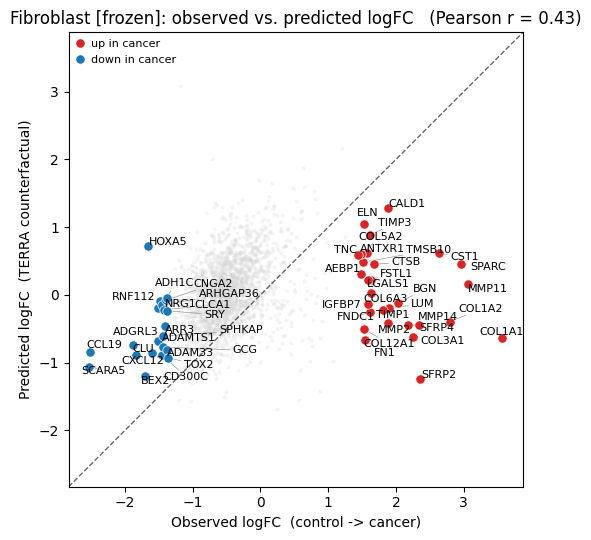

In [20]:
res_frozen = run_arm(model_dir, "frozen")

===== arm ft  (output/ft_bundle_fibroblast_96m) =====
wrote cache/crc232_emb_96m_ft_fibroblast.npz
[ft] gene shift: |universe|=8775 genes in >= 20 control cells | 0 tokens dropped (no ground truth in adata.var) | 196 perturbed genes present | self-W2=0.00e+00 | 3 random sets | 253s -> output/gene_shift_fibroblast_96m_ft.csv
         arm                    universe  n_genes  prec_at_k  pearson  spearman
ft: pipeline       (i) all token-covered     8775     0.0000  -0.0884   -0.0710
ft: random_1       (i) all token-covered     8775     0.0000  -0.0832   -0.0478
ft: random_2       (i) all token-covered     8775     0.0000  -0.0690   -0.0397
ft: random_3       (i) all token-covered     8775     0.0000  -0.0533   -0.0222
  ft: chance       (i) all token-covered     8775     0.0057      NaN       NaN
ft: pipeline      (ii) n decoder HVG2000     1866     0.0000  -0.1150   -0.0703
ft: random_1      (ii) n decoder HVG2000     1866     0.0000  -0.1401   -0.0653
ft: random_2      (ii) n decoder H

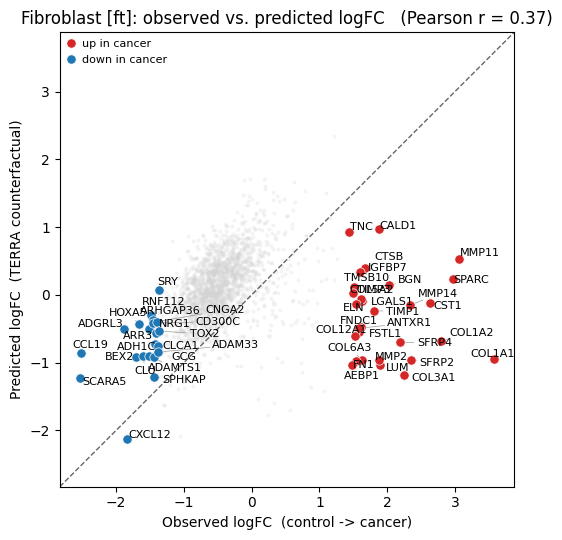

In [21]:
res_ft = run_arm(BUNDLE_DIR, "ft")

## 10. Verification (`FINETUNE_PLAN.md` §9)

Checks 1–3 (pre-flight `strict=True` load of the patched construction, the `_LoadGuard` runtime assert,
and the post-repack load) run inside `finetune_terra.py` and are recorded in `ft_summary.json`.
Checks 4–8 are re-reported here from the values the two arms recorded; 6, 7 and 8 also assert in place.
Check 5 is the one that catches a silently-failed patch: a random encoder still trains, still reports a
falling loss, and still produces embeddings — they are just uninformative.

In [22]:
f = res_frozen["scemb"]; t = res_ft["scemb"]

# 4: fine-tuned embeddings differ from frozen at all
print(f"check 4  max|delta| spatial_cell_emb (ft vs frozen) : {np.abs(t - f).max():.3e}   (> 0)")
assert np.abs(t - f).max() > 0, "ft embeddings are identical to frozen -- the encoder did not move"

# 5: ... and are ADAPTED, not random (a random encoder would give cosine ~ 0)
cos = (t * f).sum(1) / (np.linalg.norm(t, axis=1) * np.linalg.norm(f, axis=1) + 1e-12)
print(f"check 5a mean cosine(ft, frozen) spatial_cell_emb    : {cos.mean():.4f}   (>> 0; random ~ 0)")
print(f"check 5b decoder per-gene Pearson  frozen={res_frozen['ceiling']:.4f}  "
      f"ft={res_ft['ceiling']:.4f}   (frozen 112M/Myeloid reference 0.0569 -- not collapsed)")
assert cos.mean() > 0.1, "ft embeddings are near-orthogonal to frozen -- encoder may be random"

for r in (res_frozen, res_ft):
    d = r["delta_emb"]
    print(f"check 6  [{r['variant']:6s}] max|delta| cell_emb={d['cell_emb']:.3e} (<1e-5)  "
          f"spatial_cell_emb={d['spatial_cell_emb']:.3e} (>1e-5)  "
          f"neighborhood_emb={d['neighborhood_emb']:.3e} (>1e-5)")
    print(f"check 7  [{r['variant']:6s}] test h5ad n_obs={r['n_test']:,} == "
          f"is_holdout.sum()={int(is_holdout.sum()):,}")

print(f"check 8  logFC finite : {bool(np.isfinite(logfc).all())}")
assert np.isfinite(logfc).all()

check 4  max|delta| spatial_cell_emb (ft vs frozen) : 3.488e+00   (> 0)
check 5a mean cosine(ft, frozen) spatial_cell_emb    : 0.4791   (>> 0; random ~ 0)
check 5b decoder per-gene Pearson  frozen=0.0573  ft=0.0522   (frozen 112M/Myeloid reference 0.0569 -- not collapsed)
check 6  [frozen] max|delta| cell_emb=0.000e+00 (<1e-5)  spatial_cell_emb=1.226e+00 (>1e-5)  neighborhood_emb=1.262e+00 (>1e-5)
check 7  [frozen] test h5ad n_obs=20,695 == is_holdout.sum()=20,695
check 6  [ft    ] max|delta| cell_emb=0.000e+00 (<1e-5)  spatial_cell_emb=2.956e+00 (>1e-5)  neighborhood_emb=2.866e+00 (>1e-5)
check 7  [ft    ] test h5ad n_obs=20,695 == is_holdout.sum()=20,695
check 8  logFC finite : True


In [23]:
# check 9: fine-tuning val accuracy must beat the `typ` majority-class rate.
summary = json.loads(FT_SUMMARY.read_text())
print(json.dumps(summary, indent=2))

acc, maj = summary["final_val_accuracy"], summary["val_majority_class_rate"]
print(f"\ncheck 9  val accuracy = {acc:.4f}   majority-class rate = {maj:.4f}   "
      f"(above majority: {summary['val_accuracy_above_majority']})")
assert acc > maj, "val accuracy at or below the majority-class rate"

{
  "val_accuracy_per_epoch": [
    "Epoch [1/5], Train Loss: 0.1664, Train Acc: 0.9241, Val Loss: 0.1187, Val Acc: 0.9481",
    "Epoch [2/5], Train Loss: 0.1049, Train Acc: 0.9541, Val Loss: 0.1015, Val Acc: 0.9594",
    "Epoch [3/5], Train Loss: 0.0858, Train Acc: 0.9637, Val Loss: 0.0907, Val Acc: 0.9629",
    "Epoch [4/5], Train Loss: 0.0720, Train Acc: 0.9700, Val Loss: 0.0799, Val Acc: 0.9674",
    "Epoch [5/5], Train Loss: 0.0595, Train Acc: 0.9752, Val Loss: 0.0752, Val Acc: 0.9699"
  ],
  "final_val_accuracy": 0.9698795180722891,
  "val_majority_class_rate": 0.6743702081051479,
  "n_train": 82164,
  "n_val": 9130,
  "classes": [
    "232_CRC",
    "232_REF"
  ],
  "num_classes": 2,
  "trainable_params": 1772928,
  "total_params": 31438848,
  "wall_seconds": 5796.4594004154205,
  "train_seconds": 5254.397827625275,
  "val_seconds": 446.0684759616852,
  "steps_per_epoch": 822,
  "seconds_per_step": 1.2784422938261009,
  "peak_gpu_gib": 9.445308208465576,
  "epochs_run": 5,
  "ch

## 11. Results

**The primary metric is `pearson(true_lfc, pred_lfc − null_lfc)`** (`pearson_minus_null`), not the headline
`pearson`. Plan §8: the headline number is saturated by a shared `−log2(mean_control)` term that dominates
both sides of `get_lfc` (`pearson(true_lfc, −log2 mean_control) = 0.407` on the frozen 112M/Myeloid run),
which is why a **constant** train-mean profile scored **0.874** and the decoder on **random cells'**
embeddings scored **0.882** there, against the pipeline's 0.839. The null is the decode of the *unperturbed*
re-embed of the same control cells, so `pred − null` differs only by the intervention: every prior cancels,
and a constant baseline is identically zero. Frozen 112M/Myeloid reference for the primary metric: **0.478**.

Compare **frozen vs. ft on `pearson_minus_null`**. The baseline rows (B per arm; A and A' TERRA-free,
computed once) are there to show how much of any `pearson` column needs no model at all.

In [24]:
tbl = pd.DataFrame(res_frozen["rows"] + res_ft["rows"]).set_index("arm")
print(f"decoder fidelity ceiling:  frozen={res_frozen['ceiling']:.4f}   ft={res_ft['ceiling']:.4f}")
print(f"PRIMARY  pearson(true, pred-null):  "
      f"frozen={res_frozen['rows'][0]['pearson_minus_null']:+.4f}   "
      f"ft={res_ft['rows'][0]['pearson_minus_null']:+.4f}")
display(tbl.round(4))

# --- section 8b: paper-style gene-embedding shift (W2, unsigned; no decoder) ---
gs = (pd.concat([res_frozen["gene_shift"], res_ft["gene_shift"]])
        .set_index(["universe", "arm"]).sort_index())
print(f"\ngene-embedding shift (protocol B), precision@{GS_K} and correlation vs |log2FC|:")
gs.round(4)


decoder fidelity ceiling:  frozen=0.0573   ft=0.0522
PRIMARY  pearson(true, pred-null):  frozen=+0.5854   ft=+0.5292
gene-embedding shift (protocol B), precision@50 and correlation vs |log2FC|:


,pearson,spearman,prec_at_20,dir_match,pearson_minus_null
arm,,,,,
frozen: pipeline (perturbed),0.4305,0.3363,0.00,0.6667,0.5854
frozen: null (unperturbed re-embed),0.1363,0.0370,0.05,0.0000,NaN
frozen: B decoder on RANDOM cells' emb,0.7114,0.7164,0.00,1.0000,NaN
frozen: A train-set MEAN profile (no TERRA),0.3360,0.4652,0.00,0.8333,NaN
frozen: A' control's own mean (no change),0.2155,0.1213,0.05,0.8333,NaN
ft: pipeline (perturbed),0.3660,0.2617,0.05,1.0000,0.5292
ft: null (unperturbed re-embed),-0.0960,-0.1087,0.10,0.0000,NaN
ft: B decoder on RANDOM cells' emb,0.7288,0.7248,0.05,1.0000,NaN


n_genes  prec_at_k  pearson  \
universe                    arm                                             
(i) all token-covered       frozen: chance       3274     0.0153      NaN   
                            frozen: pipeline     3274     0.0000  -0.1658   
                            frozen: random_1     3274     0.0000  -0.1536   
                            frozen: random_2     3274     0.0000  -0.1456   
                            frozen: random_3     3274     0.0000  -0.1415   
                            ft: chance           8775     0.0057      NaN   
                            ft: pipeline         8775     0.0000  -0.0884   
                            ft: random_1         8775     0.0000  -0.0832   
                            ft: random_2         8775     0.0000  -0.0690   
                            ft: random_3         8775     0.0000  -0.0533   
(ii) n decoder HVG2000      frozen: chance        728     0.0687      NaN   
                            frozen: pipeline      728     0.0200  -0.2087   
                            frozen: random_1      728     0.0200  -0.2121   
                            frozen: random_2      728     0.0200  -0.1834   
                            frozen: random_3      728     0.0200  -0.1879   
                            ft: chance           1866     0.0268      NaN   
                            ft: pipeline         1866     0.0000  -0.1150   
                            ft: random_1         1866     0.0000  -0.1401   
                            ft: random_2         1866     0.0000  -0.1207   
                            ft: random_3         1866     0.0000  -0.1078   
(iii) minus perturbed genes frozen: chance       3126     0.0160      NaN   
                            frozen: pipeline     3126     0.0000  -0.1638   
                            frozen: random_1     3126     0.0000  -0.1439   
                            frozen: random_2     3126     0.0000  -0.1339   
                            frozen: random_3     3126     0.0000  -0.1324   
                            ft: chance           8579     0.0058      NaN   
                            ft: pipeline         8579     0.0000  -0.0806   
                            ft: random_1         8579     0.0000  -0.0720   
                            ft: random_2         8579     0.0000  -0.0554   
                            ft: random_3         8579     0.0000  -0.0419   

                                              spearman  
universe                    arm                         
(i) all token-covered       frozen: chance         NaN  
                            frozen: pipeline   -0.1316  
                            frozen: random_1   -0.1250  
                            frozen: random_2   -0.1102  
                            frozen: random_3   -0.1066  
                            ft: chance             NaN  
                            ft: pipeline       -0.0710  
                            ft: random_1       -0.0478  
                            ft: random_2       -0.0397  
                            ft: random_3       -0.0222  
(ii) n decoder HVG2000      frozen: chance         NaN  
                            frozen: pipeline   -0.1606  
                            frozen: random_1   -0.1655  
                            frozen: random_2   -0.1238  
                            frozen: random_3   -0.1220  
                            ft: chance             NaN  
                            ft: pipeline       -0.0703  
                            ft: random_1       -0.0653  
                            ft: random_2       -0.0534  
                            ft: random_3       -0.0302  
(iii) minus perturbed genes frozen: chance         NaN  
                            frozen: pipeline   -0.1270  
                            frozen: random_1   -0.1131  
                            frozen: random_2   -0.0989  
                            frozen: random_3   -0.0951  
                            ft: chance    